# Predicting Hotel Cancellations
Capstone Project Two : Springboard Data Science career track
Notebook by Luis Vallesteros

## 1. Problem to Solve
Can I design a model built to classify a cancellation for a given hotel?

## 2. Questions to Address
### Lead Time Analysis:

How does the lead time (the number of days between booking and arrival) affect the likelihood of a booking being canceled?
Guest Profile:

Do repeated guests have a lower cancellation rate compared to new guests?
How do the number of special requests influence the cancellation rate?
Booking Details:

### How does the type of meal plan selected affect cancellation rates?
Is there a correlation between the number of weekend nights or weeknights booked and the cancellation rate?
Does the market segment type (e.g., online, offline) influence the likelihood of cancellations?
### Room and Price:

Does the room type reserved have any impact on the cancellation rate?
How does the average price per room affect the probability of cancellation?
Parking and Extras:

Do guests who require a car parking space have a different cancellation rate compared to those who do not?
### Booking History:

How do previous cancellations or bookings not canceled influence the current booking's cancellation probability?
### Temporal Factors:

Are there any seasonal trends or specific dates with higher cancellation rates?
How does the date of arrival affect the likelihood of cancellation?
### Family and Group Dynamics:

Does the number of adults or children in a booking influence the cancellation rate?



In [24]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

In [2]:
#Loading previously cleansed data data:
hotel_data = pd.read_csv('Cleaned_Hotel_Reservations.csv')

#Head?
hotel_data.head()
hotel_data.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'date_of_arrival'],
      dtype='object')

In [3]:
#Defining our response variable

hotel_data['booking_status'] = hotel_data['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

hotel_data.head(20)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date_of_arrival
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,0,2017-10-02
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0,2018-11-06
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,1,2018-02-28
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,1,2018-05-20
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,1,2018-04-11
5,INN00006,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,1,2018-09-13
6,INN00007,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,0,2017-10-15
7,INN00008,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,0,2018-12-26
8,INN00009,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,0,2018-07-06
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,0,2018-10-18


In [4]:
# Check for missing values
print(hotel_data.isnull().sum())

# Basic statistics
print(hotel_data.describe())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
date_of_arrival                         0
dtype: int64
       no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
count  36275.000000    36275.000000          36275.000000       36275.000000   
mean       1.844962        0.105279              0.810724           2.204300   
std        0.518715        0.4026

In [5]:
hotel_data = hotel_data.drop(columns=['Booking_ID'])

hotel_data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date_of_arrival
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,0,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0,2018-11-06
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,1,2018-02-28
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,1,2018-05-20
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,1,2018-04-11


In [6]:
# Encode categorical features
hotel_data = pd.get_dummies(hotel_data, columns=['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'])

In [7]:
hotel_data.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,0,0,0,65.00,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,0,0,0,106.68,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,0,0,0,60.00,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,0,0,0,100.00,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,0,0,0,94.50,...,False,False,False,False,False,False,False,False,False,True
5,2,0,0,2,0,346,0,0,0,115.00,...,False,False,False,False,False,False,False,False,False,True
6,2,0,1,3,0,34,0,0,0,107.55,...,False,False,False,False,False,False,False,False,False,True
7,2,0,1,3,0,83,0,0,0,105.61,...,False,True,False,False,False,False,False,False,False,True
8,3,0,0,4,0,121,0,0,0,96.90,...,False,False,False,False,False,False,False,False,True,False
9,2,0,0,5,0,44,0,0,0,133.44,...,False,True,False,False,False,False,False,False,False,True


In [9]:
# Defining response variable
y = hotel_data['booking_status']

# Selecting features (excluding 'booking_status')
features = hotel_data.columns.drop('booking_status')
X = hotel_data[features]

# Check the first few rows to confirm
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,0,0,0,65.00,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,0,0,0,106.68,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,0,0,0,60.00,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,0,0,0,100.00,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,0,0,0,94.50,...,False,False,False,False,False,False,False,False,False,True


In [12]:
X.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'date_of_arrival',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online'],
      dtype='object')

In [11]:
y.head(10)

0    0
1    0
2    1
3    1
4    1
5    1
6    0
7    0
8    0
9    0
Name: booking_status, dtype: int64

In [14]:
# Drop date_of_arrival columns
X = X.drop(columns=[col for col in X.columns if 'date_of_arrival' in col])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Time to Apply the Models!

### Logistic Regression:

In [15]:
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression")
print(classification_report(y_test, y_pred_logreg))
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      4839
           1       0.75      0.61      0.67      2416

    accuracy                           0.80      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255

Accuracy: 0.8035837353549277


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Train random forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Classifier")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Classifier
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4839
           1       0.86      0.79      0.83      2416

    accuracy                           0.89      7255
   macro avg       0.88      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255

Accuracy: 0.8894555478980014


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

# Train gradient boosting model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_gb = gb.predict(X_test_scaled)
print("Gradient Boosting Classifier")
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting Classifier
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4839
           1       0.83      0.68      0.75      2416

    accuracy                           0.85      7255
   macro avg       0.84      0.81      0.82      7255
weighted avg       0.84      0.85      0.84      7255

Accuracy: 0.8463128876636802


Logistic Regression
[[4355  484]
 [ 941 1475]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      4839
           1       0.75      0.61      0.67      2416

    accuracy                           0.80      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255

Accuracy: 0.8035837353549277
ROC-AUC Score: 0.862004902222423

Random Forest Classifier
[[4533  306]
 [ 496 1920]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4839
           1       0.86      0.79      0.83      2416

    accuracy                           0.89      7255
   macro avg       0.88      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255

Accuracy: 0.8894555478980014
ROC-AUC Score: 0.9482517100298484

Gradient Boosting Classifier
[[4491  348]
 [ 767 1649]]
              precision    recall  f1-score   support

         

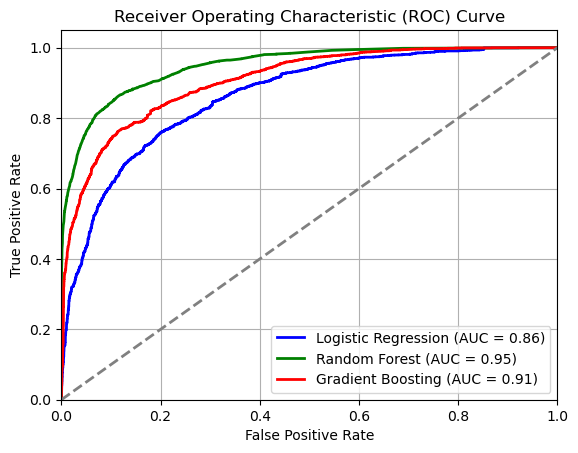

In [34]:
# Logistic Regression
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
roc_auc_logreg = roc_auc_score(y_test, y_pred_prob_logreg)
print("ROC-AUC Score:", roc_auc_logreg)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_prob_logreg)
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')

# Random Forest
print("\nRandom Forest Classifier")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
print("ROC-AUC Score:", roc_auc_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Gradient Boosting
print("\nGradient Boosting Classifier")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
roc_auc_gb = roc_auc_score(y_test, y_pred_prob_gb)
print("ROC-AUC Score:", roc_auc_gb)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_prob_gb)
plt.plot(fpr_gb, tpr_gb, color='red', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# 4. Final Comparison of Models

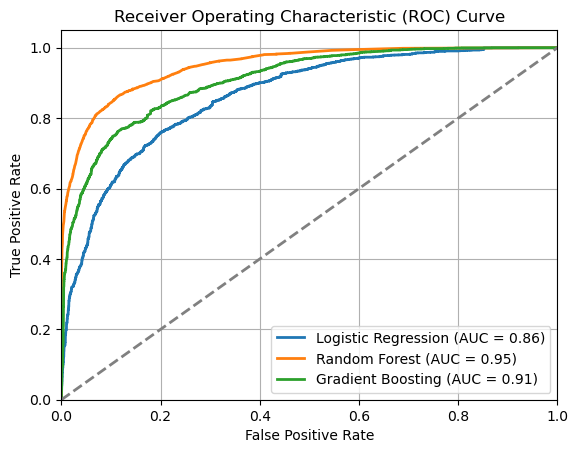

                 Model  Accuracy  Precision    Recall  F1 Score  ROC-AUC Score
0  Logistic Regression  0.803584   0.752935  0.610513  0.674286       0.862005
1        Random Forest  0.889456   0.862534  0.794702  0.827230       0.948252
2    Gradient Boosting  0.846313   0.825739  0.682533  0.747337       0.906319


In [38]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC-AUC Score': []
}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1 Score'].append(f1)
    metrics['ROC-AUC Score'].append(roc_auc)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
    
    # Plot ROC curves
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

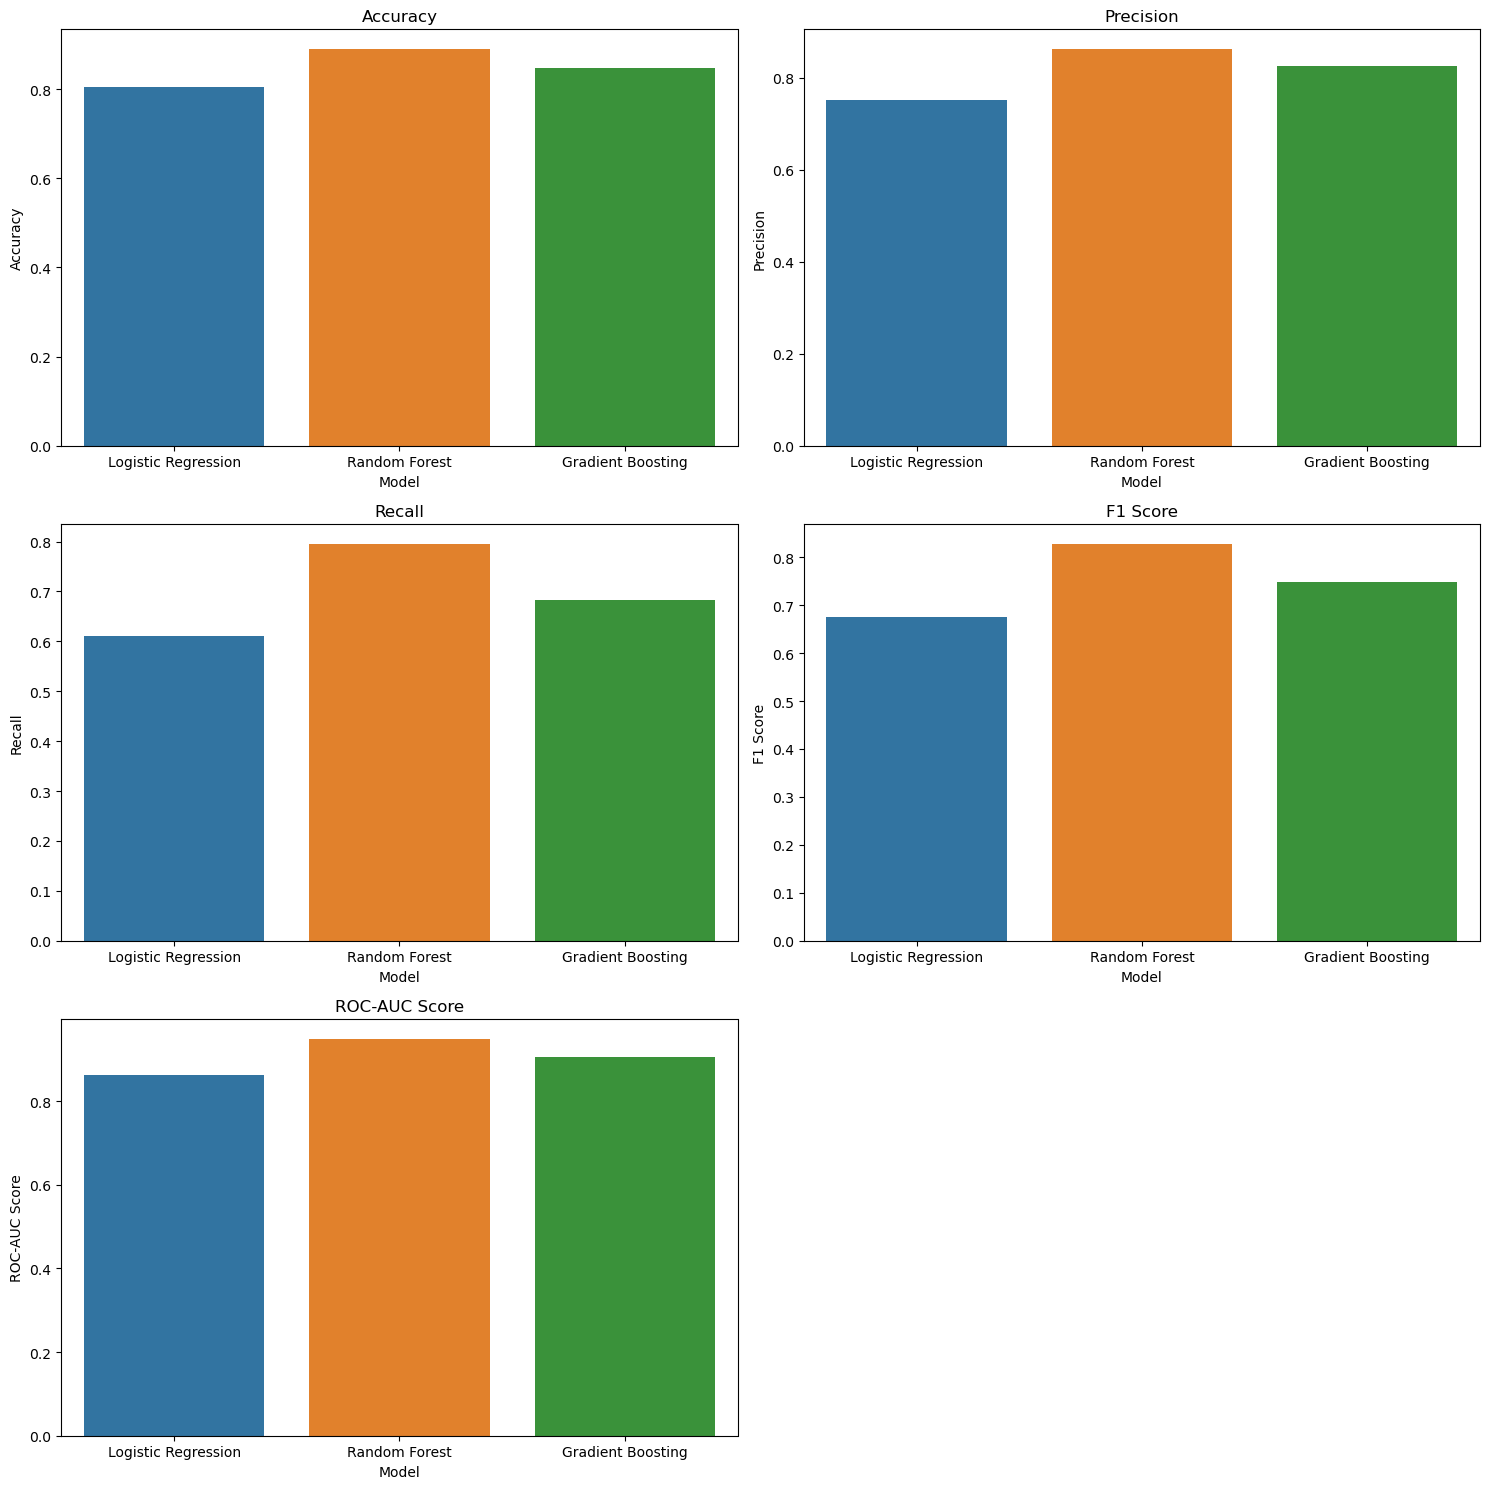

In [39]:
# Set up the matplotlib figure
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Plot Accuracy
sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0, 0])
axes[0, 0].set_title('Accuracy')

# Plot Precision
sns.barplot(x='Model', y='Precision', data=metrics_df, ax=axes[0, 1])
axes[0, 1].set_title('Precision')

# Plot Recall
sns.barplot(x='Model', y='Recall', data=metrics_df, ax=axes[1, 0])
axes[1, 0].set_title('Recall')

# Plot F1 Score
sns.barplot(x='Model', y='F1 Score', data=metrics_df, ax=axes[1, 1])
axes[1, 1].set_title('F1 Score')

# Plot ROC-AUC Score
sns.barplot(x='Model', y='ROC-AUC Score', data=metrics_df, ax=axes[2, 0])
axes[2, 0].set_title('ROC-AUC Score')

# Hide the empty subplot
axes[2, 1].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

It looks like we have a clear winner here - Random Forest seems to show the strongest model.

### 5. Feature Importance

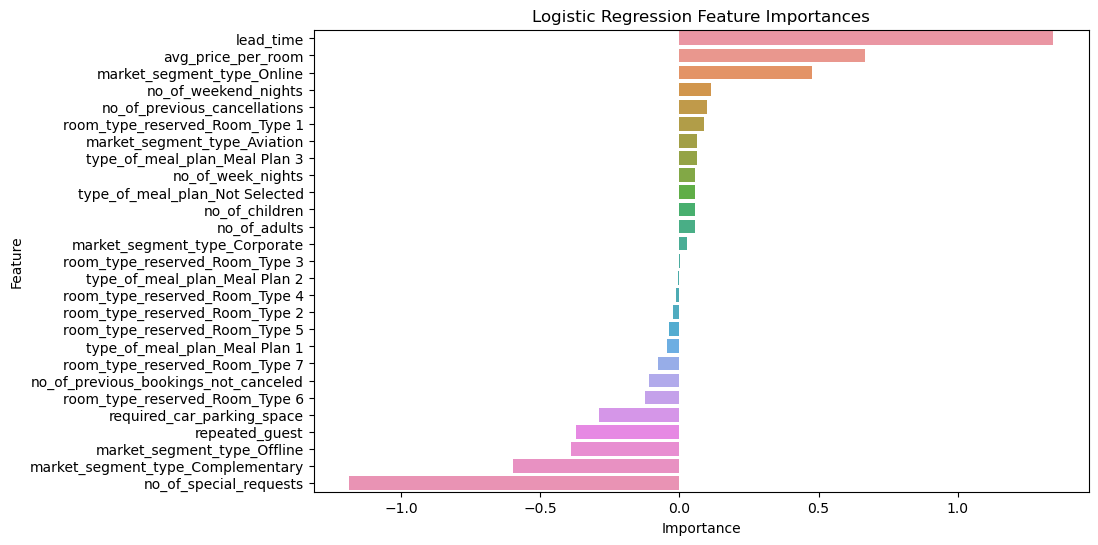

In [43]:
# Get feature importances (coefficients)
coefficients = logreg.coef_[0]

# Creating a DataFrame for visualization
logreg_importances = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients})
logreg_importances = logreg_importances.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=logreg_importances['Importance'], y=logreg_importances['Feature'])
plt.title('Logistic Regression Feature Importances')
plt.show()

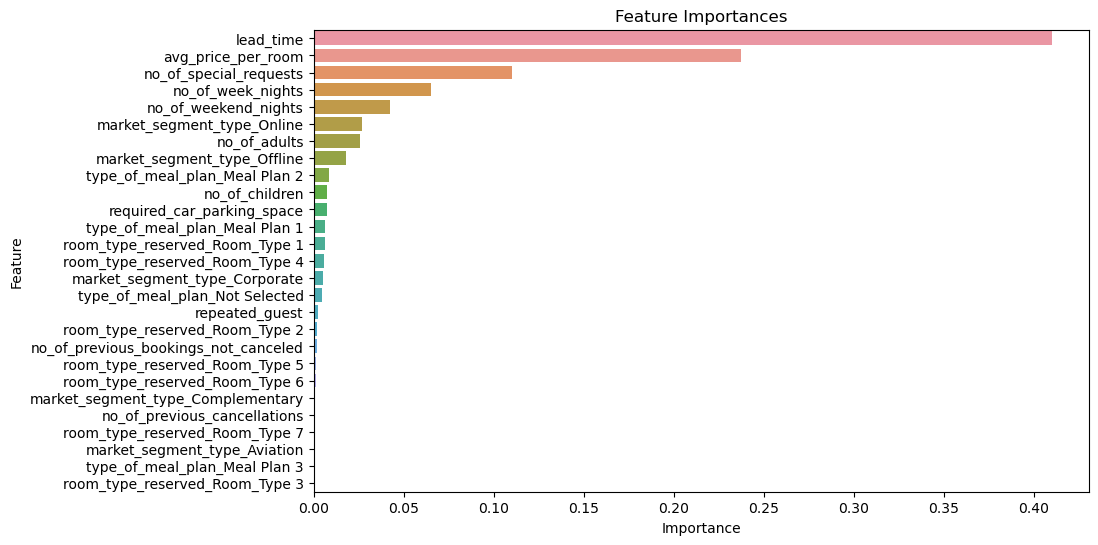

In [42]:
# Getting feature importances for Random Forest
importances = rf.feature_importances_

# Creating a DataFrame for visualization
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'])
plt.title('Feature Importances')
plt.show()

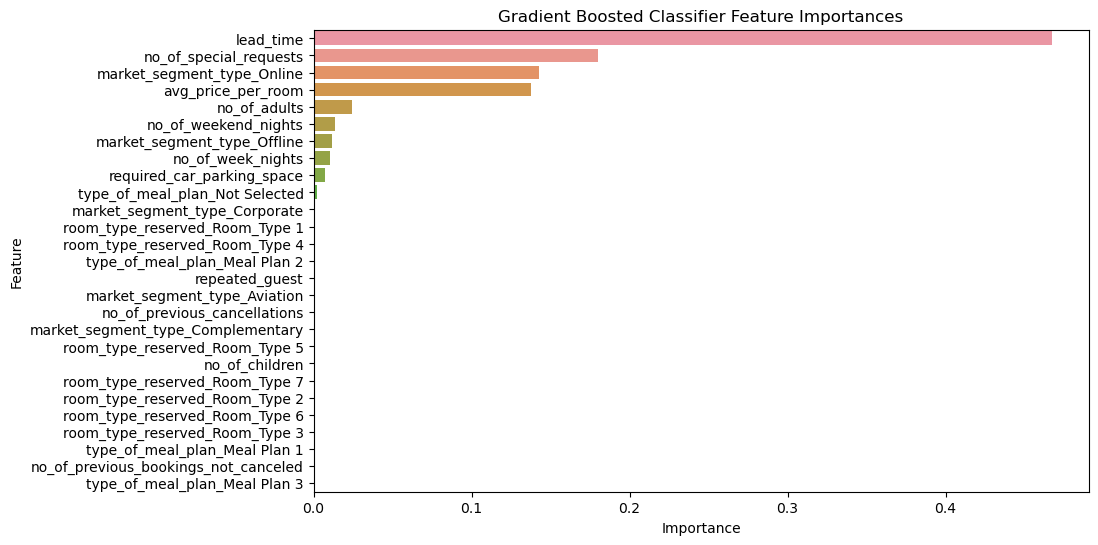

In [45]:
# Get feature importances
gboost_importances = gb.feature_importances_

# Creating a DataFrame for visualization
gboost_importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': gboost_importances})
gboost_importances_df = gboost_importances_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=gboost_importances_df['Importance'], y=gboost_importances_df['Feature'])
plt.title('Gradient Boosted Classifier Feature Importances')
plt.show()

# 5. Conclusions

In this project, we aimed to predict hotel booking cancellations using a dataset containing various booking details, guest information, and booking status. Accurate predictions of cancellations can help hotels manage their resources more effectively and improve customer satisfaction.

## Model Performance
After experimenting with several models, the Random Forest emerged as the best-performing model with an accuracy of 89%, a precision of 86%, and a recall of 79%. This model's ability to handle complex interactions between features and its robustness to overfitting made it particularly well-suited for this task.

## Feature Importance
The feature importance analysis revealed that certain features significantly influenced the likelihood of a booking cancellation. The top features included:

Lead Time: Longer lead times were strongly associated with a higher likelihood of cancellation.

Average price per room: More expensive prices were more strongly associated with high cancellation times.

Booked online: those who booked online tended to be associated with higher cancellation times.

## Key Findings
Several interesting patterns emerged from the analysis:

Lead Time: There is a positive correlation between the lead time and the probability of cancellation, suggesting that bookings made far in advance are more prone to cancellation.

Customer Type: Repeat customers had a lower cancellation rate compared to new customers, indicating the importance of customer loyalty programs.

Market Segment: Bookings from certain market segments, such as online travel agents, had higher cancellation rates, which could inform targeted strategies for these segments.

## Limitations
This study has some limitations. The dataset may not capture all relevant features influencing cancellations, such as economic factors or competitor pricing. Additionally, the data might have inherent biases, such as an overrepresentation of certain types of bookings.

## Future Work
Future research could enhance this model by incorporating additional data sources, such as customer reviews and external economic indicators. Exploring advanced techniques like ensemble learning and deep learning could further improve predictive performance. Additionally, implementing real-time prediction systems could provide immediate insights for hotel management.

